In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

joblib_name = 'empty' 

# Load your dataset
df = pd.read_csv(f'..\\PCA Feature Extraction\\pca_features_{joblib_name}.csv') 
# df = df.iloc[:540, :]  # Keep only the first 542 rows without HD

# Define feature groups
features_wcc = ['wcc_m1']
# features_pca = ['pca_peak_amp_m1',  'pca_peak_amp_m2', 'pca_peak_amp_m3']# 'pca_peak_freq_m1','pca_peak_freq_m2', 'pca_peak_freq_m3'
# features_sensor = [f'pt{i}_peak_amp_m1' for i in range(1, 10)]
# df['pt2/8'] = df['pt2_peak_amp_m1'] / df['pt8_peak_amp_m1']
# df['pt4/6'] = df['pt4_peak_amp_m1'] / df['pt6_peak_amp_m1']
# df['pt1/7'] = df['pt1_peak_amp_m1'] / df['pt7_peak_amp_m1'] 
# df['pt1/3'] = df['pt1_peak_amp_m1'] / df['pt3_peak_amp_m1']

ratio = ['pt2/8', 'pt4/6']
# ratio = ['pt1/3', 'pt3/9', 'pt1/7', 'pt7/9']
X = df[features_wcc + ratio]

# Define target (Change to 'severity' for Severity Test or 'case' for Location Test)
y = df['case'] 

# Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling features (Crucial for SVM, helpful for RF visualization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

FileNotFoundError: [Errno 2] No such file or directory: '..\\PCA Feature Extraction\\pca_features_empty.csv'

C:\Users\ycwon\AppData\Local\Temp\ipykernel_28872\2801017938.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


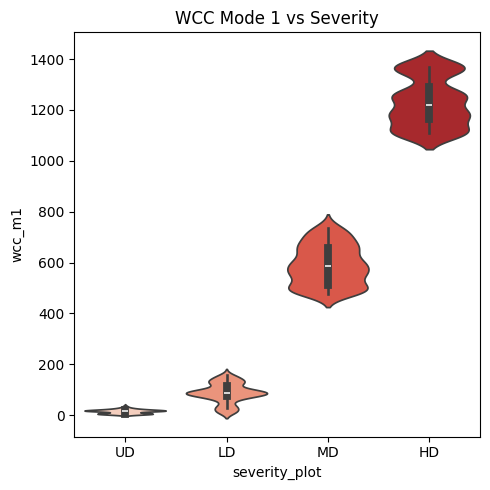

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.violinplot(
    ax=ax,
    x='severity_plot',
    y='wcc_m1',
    data=df,
    palette='Reds',
    order=['UD', 'LD', 'MD', 'HD'],
    legend=False
)

ax.set_title('WCC Mode 1 vs Severity')
plt.tight_layout()
plt.show()

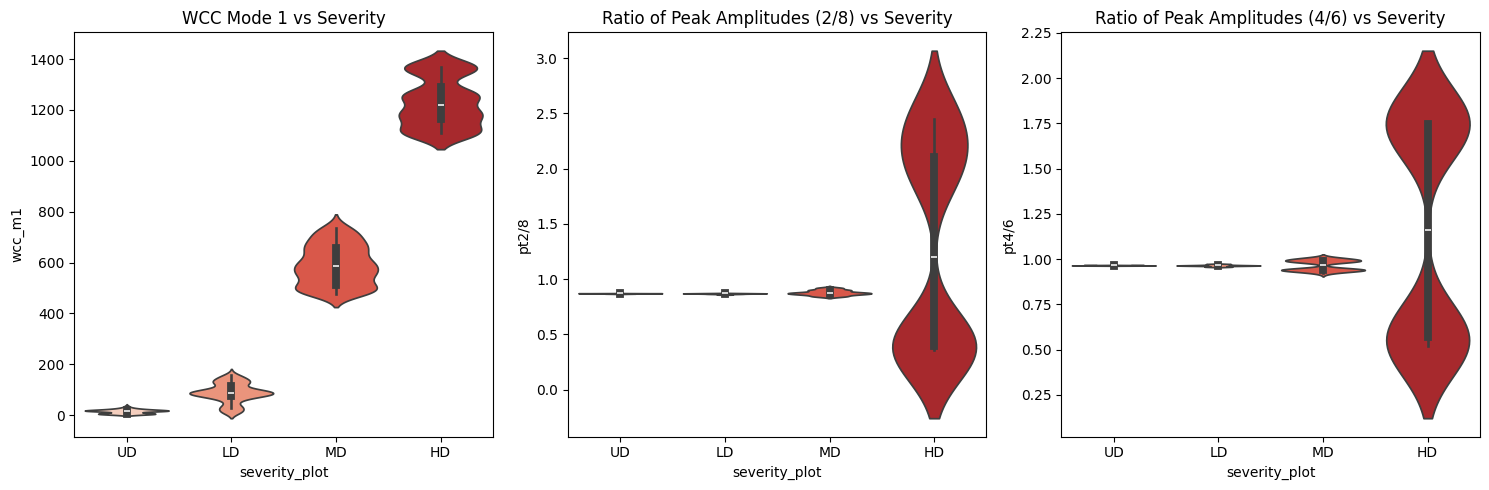

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Row 1: Severity Studies (for frequency) ---
sns.violinplot(ax=axes[0], x='severity_plot', y='wcc_m1', data=df, palette='Reds', order=['UD', 'LD', 'MD', 'HD'], hue='severity_plot', legend=False)
axes[0].set_title('WCC Mode 1 vs Severity')

sns.violinplot(ax=axes[1], x='severity_plot', y='pt2/8', data=df, palette='Reds', order=['UD', 'LD', 'MD', 'HD'], hue='severity_plot', legend=False)
axes[1].set_title('Ratio of Peak Amplitudes (2/8) vs Severity')

sns.violinplot(ax=axes[2], x='severity_plot', y='pt4/6', data=df, palette='Reds', order=['UD', 'LD', 'MD', 'HD'], hue='severity_plot', legend=False)
axes[2].set_title('Ratio of Peak Amplitudes (4/6) vs Severity')

plt.tight_layout()
plt.show()

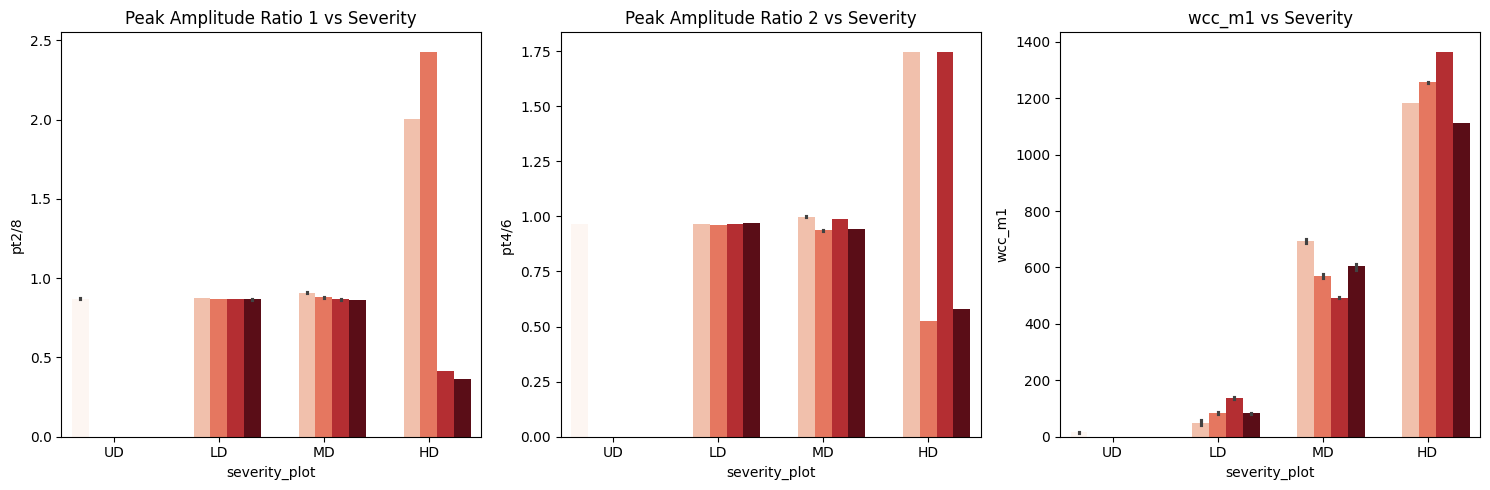

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df['pt2/8'] = df['pt2_peak_amp_m1'] / df['pt8_peak_amp_m1']
df['pt4/6 '] = df['pt4_peak_amp_m1'] / df['pt6_peak_amp_m1']
df['pt1/7'] = df['pt1_peak_amp_m1'] / df['pt7_peak_amp_m1'] 
df['pt1/3'] = df['pt1_peak_amp_m1'] / df['pt3_peak_amp_m1']

sns.barplot(ax=axes[0], x='severity_plot', y='pt2/8', data=df, palette='Reds', order=['UD', 'LD', 'MD', 'HD'], hue='damage_location', legend=False)
axes[0].set_title('Peak Amplitude Ratio 1 vs Severity')

sns.barplot(ax=axes[1], x='severity_plot', y='pt4/6 ', data=df, palette='Reds', order=['UD', 'LD', 'MD', 'HD'], hue='damage_location', legend=False)
axes[1].set_title('Peak Amplitude Ratio 2 vs Severity')

sns.barplot(ax=axes[2], x='severity_plot', y='wcc_m1', data=df, palette='Reds', order=['UD', 'LD', 'MD', 'HD'], hue='damage_location', legend=False)
axes[2].set_title('wcc_m1 vs Severity')

plt.tight_layout()
plt.show()

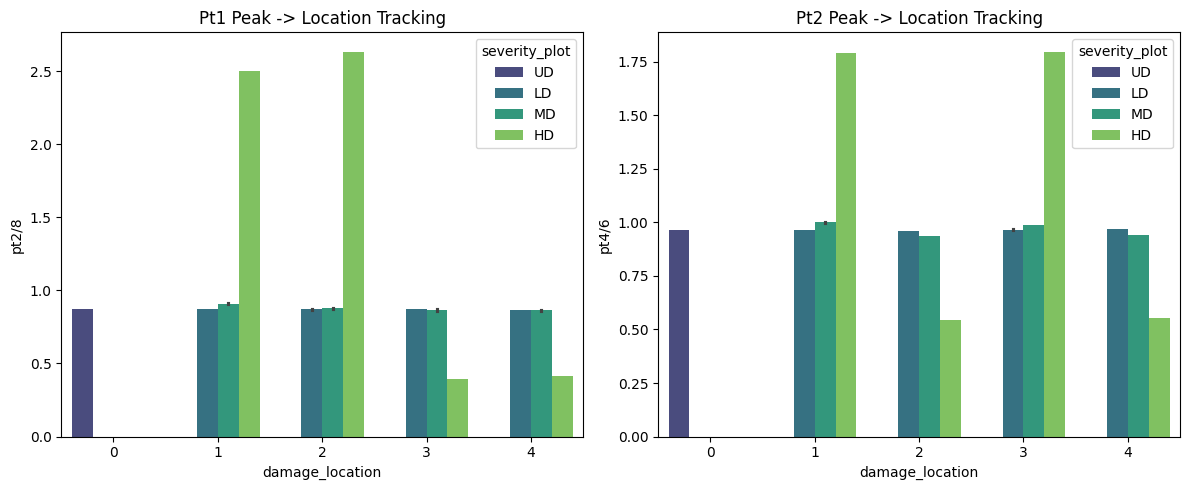

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Row 2: Location Studies ---
sns.barplot(ax=axes[0], x='damage_location', y='pt2/8', data=df, palette='viridis', hue='severity_plot', legend=True)
axes[0].set_title('Pt1 Peak -> Location Tracking')

sns.barplot(ax=axes[1], x='damage_location', y='pt4/6', data=df, palette='viridis', hue='severity_plot', legend=True)
axes[1].set_title('Pt2 Peak -> Location Tracking')

plt.tight_layout()
plt.show()

Classification Report:
               precision    recall  f1-score   support

          H1       1.00      1.00      1.00        12
          H2       1.00      1.00      1.00        12
          H3       1.00      1.00      1.00        12
          H4       1.00      1.00      1.00        12
          L1       1.00      1.00      1.00        12
          L2       1.00      1.00      1.00        12
          L3       1.00      1.00      1.00        12
          L4       1.00      1.00      1.00        12
          M1       1.00      1.00      1.00        12
          M2       1.00      1.00      1.00        12
          M3       1.00      1.00      1.00        12
          M4       1.00      1.00      1.00        12
          UD       1.00      1.00      1.00        12

    accuracy                           1.00       156
   macro avg       1.00      1.00      1.00       156
weighted avg       1.00      1.00      1.00       156



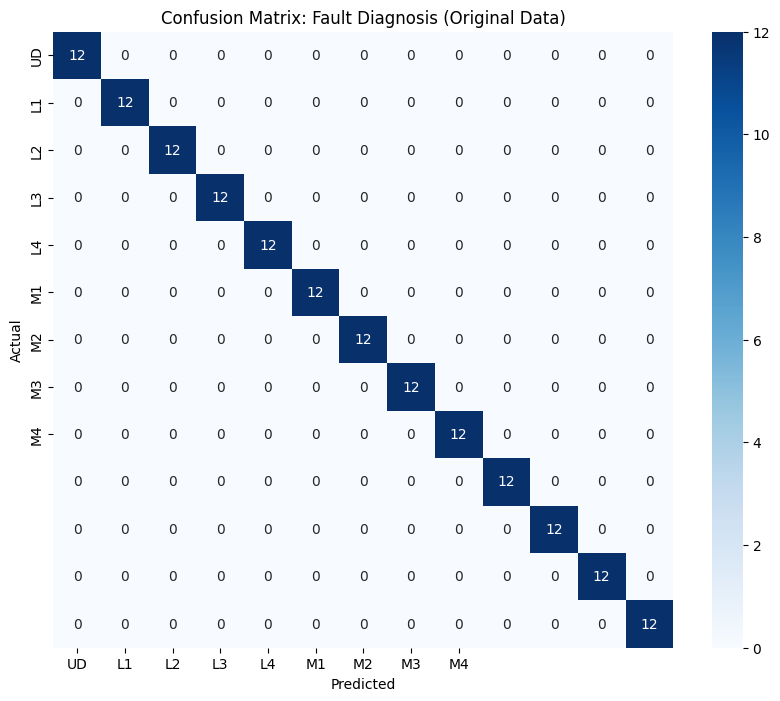

In [60]:
# Initialize and train
# class_names = ['UD', 'L1', 'L2', 'L3', 'L4', 'M1', 'M2', 'M3', 'M4', 'H1', 'H2', 'H3', 'H4']
class_names = ['UD', 'L1', 'L2', 'L3', 'L4', 'M1', 'M2', 'M3', 'M4']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix: Fault Diagnosis (Original Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

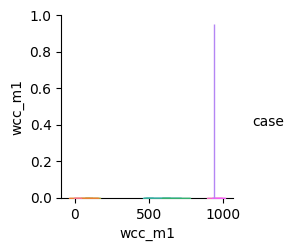

In [61]:
# Visualizing WCC features against Severity
sns.pairplot(df[features_wcc + ['case']], hue='case', diag_kind='kde')
plt.show()

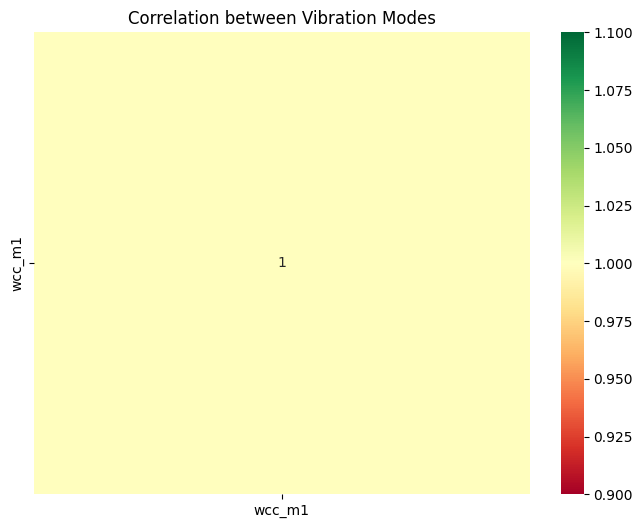

In [62]:
# Compute correlation matrix for WCC features
plt.figure(figsize=(8,6))
sns.heatmap(df[features_wcc].corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation between Vibration Modes')
plt.show()

In [63]:
# # 1. First, check the correlation of all 9 sensors
# features_sensor = [f'pt{i}_peak_amp_m1' for i in range(1, 10)]

# plt.figure(figsize=(10, 8))
# sns.heatmap(df[features_sensor].corr(), annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation Heatmap: Sensor Peaks (Local)')
# plt.show()

# # 2. Plot a "Subset" Pair Plot for Location
# # Let's pick sensors at the ends and the middle (e.g., Pt 1, 5, 9)
# subset_sensors = ['wcc_m1', 'wcc_m2', 'wcc_m3',
#                   'pt1_peak_amp_m1','pt3_peak_amp_m1', 
#                   'pt7_peak_amp_m1','pt9_peak_amp_m1']

# sns.pairplot(df[subset_sensors + ['case']], hue='case', palette='husl', diag_kind='kde')
# plt.suptitle('Local Sensor Peaks grouped by Damage Case', y=1.02)
# plt.show()

In [64]:
import joblib

# joblib_name = 'empty'
# 1. Save the model
joblib.dump(rf_model, f'{joblib_name}_damage_rf_model.pkl')

# 2. Save the scaler (this is the 'ruler' the model needs)
joblib.dump(scaler, f'{joblib_name}_damage_scaler.pkl')

['HD_damage_scaler.pkl']